In [2]:
import lightgbm

In [3]:
lightgbm.__version__

'4.6.0'

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, roc_auc_score)


import lightgbm as lgb

In [5]:
hr_data = pd.read_csv("../datasets/hr_analytics.csv")

In [6]:
hr_data

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54730,52939,Sales & Marketing,region_22,Bachelor's,m,sourcing,1,46,1.0,4,0,47,0
54731,64712,Sales & Marketing,region_2,Bachelor's,m,other,2,33,1.0,3,0,48,0
54732,72727,Operations,region_32,Bachelor's,m,sourcing,1,37,3.0,3,0,55,0
54733,52325,Sales & Marketing,region_16,Bachelor's,m,other,1,49,4.0,5,0,47,0


In [7]:
hr_data.isnull().sum()

employee_id                0
department                 0
region                     0
education               2406
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4119
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [8]:
hr_data = hr_data.drop("employee_id", axis=1)

In [9]:
hr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54735 entries, 0 to 54734
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   department            54735 non-null  object 
 1   region                54735 non-null  object 
 2   education             52329 non-null  object 
 3   gender                54735 non-null  object 
 4   recruitment_channel   54735 non-null  object 
 5   no_of_trainings       54735 non-null  int64  
 6   age                   54735 non-null  int64  
 7   previous_year_rating  50616 non-null  float64
 8   length_of_service     54735 non-null  int64  
 9   awards_won?           54735 non-null  int64  
 10  avg_training_score    54735 non-null  int64  
 11  is_promoted           54735 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 5.0+ MB


In [10]:
categorial_variables = hr_data.select_dtypes(exclude=np.number).columns.tolist()
categorial_variables

['department', 'region', 'education', 'gender', 'recruitment_channel']

In [11]:
hr_data[categorial_variables] = hr_data[categorial_variables].astype("category")
hr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54735 entries, 0 to 54734
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   department            54735 non-null  category
 1   region                54735 non-null  category
 2   education             52329 non-null  category
 3   gender                54735 non-null  category
 4   recruitment_channel   54735 non-null  category
 5   no_of_trainings       54735 non-null  int64   
 6   age                   54735 non-null  int64   
 7   previous_year_rating  50616 non-null  float64 
 8   length_of_service     54735 non-null  int64   
 9   awards_won?           54735 non-null  int64   
 10  avg_training_score    54735 non-null  int64   
 11  is_promoted           54735 non-null  int64   
dtypes: category(5), float64(1), int64(6)
memory usage: 3.2 MB


In [13]:
target_counts = hr_data["is_promoted"].value_counts()

In [14]:
target_counts

is_promoted
0    50073
1     4662
Name: count, dtype: int64

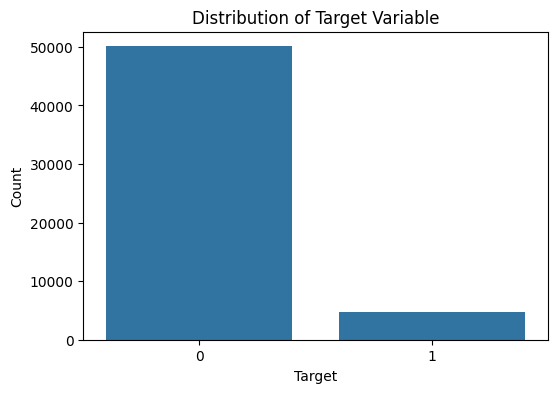

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax)

ax.set_xlabel("Target")
ax.set_ylabel("Count")
ax.set_title("Distribution of Target Variable")

plt.show()

In [18]:
X = hr_data.drop(columns="is_promoted")
y = hr_data["is_promoted"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

In [22]:
X_train.shape, X_test.shape

((38314, 11), (16421, 11))

In [41]:
lgbm_clf = lgb.LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    n_estimators=500,
    random_state=42,
    verbose=-1
)

lgbm_clf.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [27]:
def compute_metrics(clf):
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC Score": roc_auc_score(y_test, y_pred_proba),
    }

    print("Evaluation Metrics:")
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    return metrics

In [42]:
compute_metrics(lgbm_clf)

Evaluation Metrics:
Accuracy: 0.8434
Precision: 0.2953
Recall: 0.6047
F1 Score: 0.3968
ROC-AUC Score: 0.8184


{'Accuracy': 0.8433712928567079,
 'Precision': 0.29528795811518327,
 'Recall': 0.6047176554681916,
 'F1 Score': 0.3968105065666041,
 'ROC-AUC Score': 0.8183637312879876}

In [43]:
X_train_es, X_val, y_train_es, y_val = train_test_split(
    X_train, y_train, test_size=0.30, random_state=42, stratify=y_train)

X_train_es.shape, X_val.shape

((26819, 11), (11495, 11))

In [44]:
lgbm_clf = lgb.LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    n_estimators=3000,
    random_state=42,
    verbose=1
)

lgbm_clf.fit(X_train, y_train, eval_metric="f1", eval_set=(X_val, y_val), callbacks=[lgb.early_stopping(stopping_rounds=5)] )

compute_metrics(lgbm_clf)

[LightGBM] [Info] Number of positive: 3263, number of negative: 35051
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 213
[LightGBM] [Info] Number of data points in the train set: 38314, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's binary_logloss: 0.100851
Evaluation Metrics:
Accuracy: 0.9004
Precision: 0.4219
Recall: 0.4575
F1 Score: 0.4390
ROC-AUC Score: 0.7935


{'Accuracy': 0.9003714755496012,
 'Precision': 0.4218852999340804,
 'Recall': 0.45746962115796996,
 'F1 Score': 0.438957475994513,
 'ROC-AUC Score': 0.7935434272288182}

In [45]:
def compute_metrics_native(gbm, threshold=0.5):
    y_pred_proba = gbm.predict(X_test)
    y_pred = (y_pred_proba >= threshold).astype(int)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC Score": roc_auc_score(y_test, y_pred_proba),
    }

    print("Evaluation Metrics:")
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    return metrics

In [46]:
lgb_train = lgb.Dataset(X_train_es, y_train_es)

lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)

In [47]:
params = {
    "boosting_type": "gbdt",
    "objective": "binary",
    "metric": "auc",
    "num_leaves": 31,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "is_unbalance": True,
    "random_state": 42,
    "verbose": 1,
}

gbm = lgb.train(
    params, lgb_train, 
    num_boost_round=2000, 
    valid_sets=[lgb_val], 
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

compute_metrics_native(gbm)

[LightGBM] [Info] Number of positive: 2284, number of negative: 24535
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 211
[LightGBM] [Info] Number of data points in the train set: 26819, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.085164 -> initscore=-2.374172
[LightGBM] [Info] Start training from score -2.374172
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[31]	valid_0's auc: 0.821592
Evaluation Metrics:
Accuracy: 0.8317
Precision: 0.2795
Recall: 0.6183
F1 Score: 0.3850
ROC-AUC Score: 0.8175


{'Accuracy': 0.8316789476889349,
 'Precision': 0.27948303715670436,
 'Recall': 0.6182987848463188,
 'F1 Score': 0.38495772140631956,
 'ROC-AUC Score': 0.817531475637019}

## GOSS (gradient-besed one-side sampling)

In [49]:
params = {
    "boosting_type": "gbdt",
    "data_sample_strategy": "goss",
    "objective": "binary",
    "metric": "auc",
    "num_leaves": 31,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "is_unbalance": True,
    "random_state": 42,
    "verbose": 1,
}

gbm = lgb.train(
    params, lgb_train, 
    num_boost_round=2000, 
    valid_sets=[lgb_val], 
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

compute_metrics_native(gbm)

[LightGBM] [Info] Number of positive: 2284, number of negative: 24535
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001593 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 211
[LightGBM] [Info] Number of data points in the train set: 26819, number of used features: 11
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.085164 -> initscore=-2.374172
[LightGBM] [Info] Start training from score -2.374172
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[40]	valid_0's auc: 0.82598
Evaluation Metrics:
Accuracy: 0.8115
Precision: 0.2589
Recall: 0.6512
F1 Score: 0.3705
ROC-AUC Score: 0.8191


{'Accuracy': 0.8114609341696608,
 'Precision': 0.2588803637396988,
 'Recall': 0.6511794138670479,
 'F1 Score': 0.37047580317202117,
 'ROC-AUC Score': 0.8190926122268707}

In [50]:
importance_split = gbm.feature_importance(importance_type="split")
importance_gain = gbm.feature_importance(importance_type="gain")

features = lgbm_clf.booster_.feature_name()

In [52]:
df_split_importance = pd.DataFrame({
    "Feature": features,
    "Split Importance": importance_split
}).sort_values(by="Split Importance", ascending=False)

df_split_importance

,Feature,Split Importance
10,avg_training_score,305
1,region,204
6,age,194
0,department,122
8,length_of_service,121
7,previous_year_rating,101
2,education,37
9,awards_won?,32
5,no_of_trainings,30
3,gender,29


In [53]:
df_gain_importance = pd.DataFrame({
    "Feature": features,
    "Gain Importance": importance_gain
}).sort_values(by="Gain Importance", ascending=False)

df_gain_importance

,Feature,Gain Importance
10,avg_training_score,47885.223522
7,previous_year_rating,23445.689007
0,department,17377.636606
1,region,16583.102629
6,age,10088.374281
9,awards_won?,6260.768181
8,length_of_service,5558.039188
5,no_of_trainings,2318.409386
2,education,1737.120697
3,gender,1680.243910


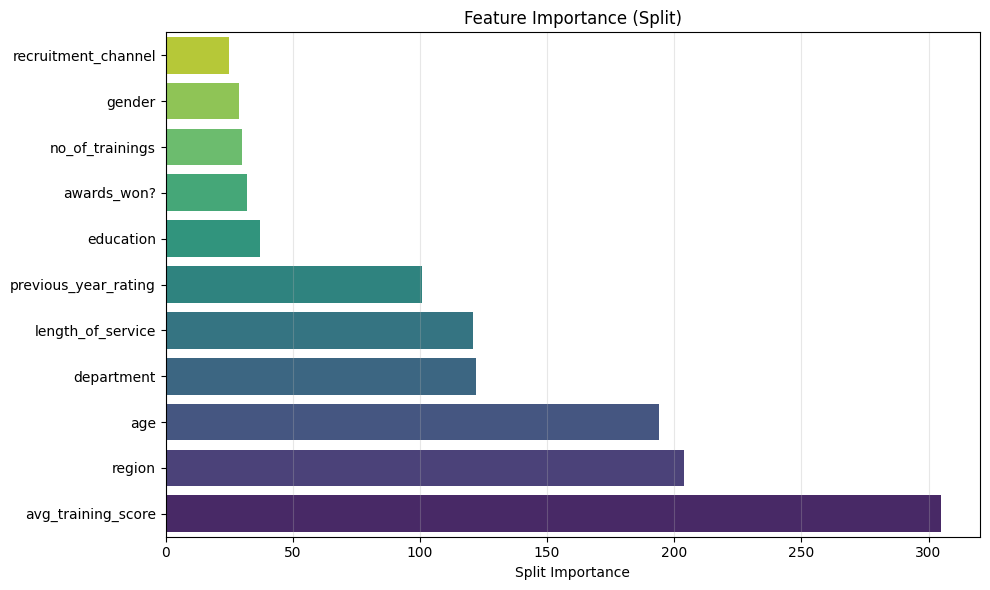

In [57]:
plot_data = df_split_importance.sort_values("Split Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="Split Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    dodge=False,
    legend=False,
    ax=ax
)

ax.set_title("Feature Importance (Split)")
ax.set_xlabel("Split Importance")
ax.set_ylabel("")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
plt.show()

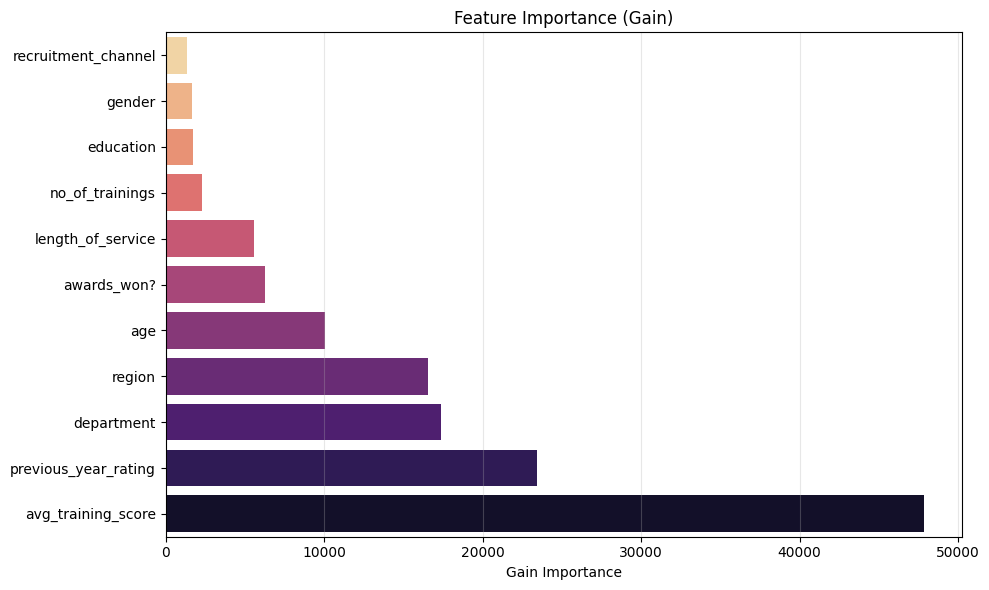

In [58]:
plot_data = df_gain_importance.sort_values("Gain Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="Gain Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    dodge=False,
    legend=False,
    ax=ax
)

ax.set_title("Feature Importance (Gain)")
ax.set_xlabel("Gain Importance")
ax.set_ylabel("")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
plt.show()